In [1]:
import numpy as np
import matplotlib.pyplot as plt
import deepxde as dde
dde.backend.set_default_backend("pytorch")

Using backend: pytorch
Other supported backends: tensorflow.compat.v1, tensorflow, jax, paddle.
paddle supports more examples now and is recommended.


Setting the default backend to "pytorch". You can change it in the ~/.deepxde/config.json file or export the DDE_BACKEND environment variable. Valid options are: tensorflow.compat.v1, tensorflow, pytorch, jax, paddle (all lowercase)


In [2]:
rho = 1
mu = 1
u_in = 1
D = 1
L = 2

In [3]:
geom = dde.geometry.Rectangle(xmin = [-L/2, -D/2], xmax = [L/2, D/2])

In [4]:
def boundary_wall(COOR, on_boundary): # COOR is [x, y]
    return on_boundary and (
        np.isclose(COOR[1], -D/2, rtol = 1e-5, atol = 1e-8) or 
        np.isclose(COOR[1], +D/2, rtol = 1e-5, atol = 1e-8)
    )

def boundary_input(COOR, on_boundary): # COOR is [x, y]
    return on_boundary and (
        np.isclose(COOR[0], -L/2, rtol = 1e-5, atol = 1e-8)
    )

def boundary_output(COOR, on_boundary): # COOR is [x, y]
    return on_boundary and (
        np.isclose(COOR[0], L/2, rtol = 1e-5, atol = 1e-8)
    )

In [5]:
BC_Wall_u = dde.DirichletBC(geom, lambda X: 0., boundary_wall, component = 0) # component = [u, v, p]
BC_Wall_v = dde.DirichletBC(geom, lambda X: 0., boundary_wall, component = 1)

BC_inlet_u = dde.DirichletBC(geom, lambda X: u_in, boundary_input, component = 0)
BC_inlet_v = dde.DirichletBC(geom, lambda X: 0., boundary_input, component = 1)

BC_outlet_p = dde.DirichletBC(geom, lambda X: 0., boundary_output, component = 2)

In [6]:
def PDE(comp, U): # comp = [x, t]
    du_dx = dde.grad.jacobian(U, comp, i=0, j=0) # i is output U = (u, v, p), j is input comp = [x, y]
    du_dy = dde.grad.jacobian(U, comp, i=0, j=1)
    
    dv_dx = dde.grad.jacobian(U, comp, i=1, j=0)
    dv_dy = dde.grad.jacobian(U, comp, i=1, j=1)

    dp_dx = dde.grad.jacobian(U, comp, i=2, j=0)
    dp_dy = dde.grad.jacobian(U, comp, i=2, j=1)

    d2u_dx2 = dde.grad.hessian(U, comp, component = 0, i=0, j=0) # component is U = (u, v, p), i is input comp = [x, y], j is input comp = [x, y]
    d2u_dy2 = dde.grad.hessian(U, comp, component = 0, i=1, j=1)
    
    d2v_dx2 = dde.grad.hessian(U, comp, component = 1, i=0, j=0)
    d2v_dy2 = dde.grad.hessian(U, comp, component = 1, i=1, j=1)

    u = U[:, 0:1]
    v = U[:, 1:2]

    X_momentum = u * du_dx + v * du_dy + (1.0/rho) * dp_dx - (mu/rho) * (d2u_dx2 + d2u_dy2)
    Y_momentum = u * dv_dx + v * dv_dy + (1.0/rho) * dp_dy - (mu/rho) * (d2v_dx2 + d2v_dy2)
    continuity = du_dx + dv_dy
    return [X_momentum, Y_momentum, continuity]

In [7]:
data = dde.data.PDE(
    geom,
    PDE,
    [BC_Wall_u, BC_Wall_v, BC_inlet_u, BC_inlet_v, BC_outlet_p],
    num_domain = 3000,
    num_boundary = 200,
    num_test = 500
)

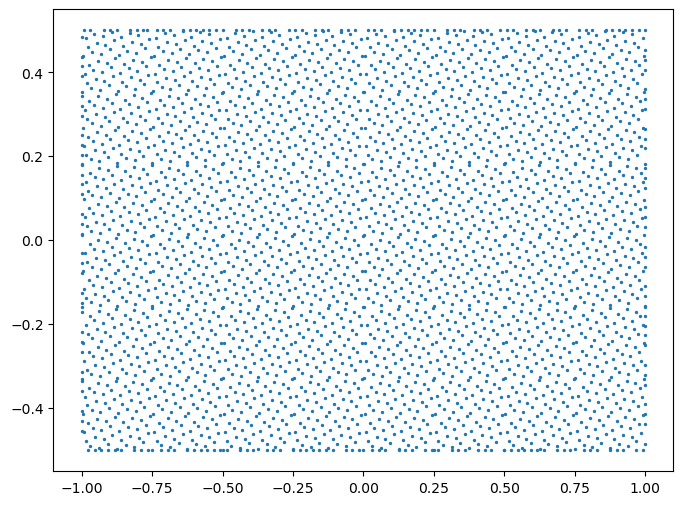

In [8]:
plt.figure(figsize=(8, 6))
plt.scatter(data.train_x_all[:, 0], data.train_x_all[:, 1], s=2)

In [9]:
network = dde.nn.FNN([2] + [100]*5 + [3], "tanh", "Glorot normal")

In [10]:
model = dde.Model(data, network)
model.compile("adam", lr=1e-3)

Compiling model...
'compile' took 0.000152 s



In [11]:
losshistory, train_state = model.train(iterations = 10000)

Training model...

Step      Train loss                                                                          Test loss                                                                           Test metric
0         [2.51e-02, 4.56e-02, 1.56e-01, 3.93e-02, 3.29e-03, 4.47e-01, 7.36e-03, 2.43e-02]    [2.51e-02, 4.60e-02, 1.58e-01, 3.93e-02, 3.29e-03, 4.47e-01, 7.36e-03, 2.43e-02]    []  
1000      [8.10e-04, 7.31e-04, 8.15e-03, 2.85e-02, 1.20e-02, 4.07e-02, 2.94e-03, 3.34e-04]    [3.67e-04, 4.49e-04, 5.33e-03, 2.85e-02, 1.20e-02, 4.07e-02, 2.94e-03, 3.34e-04]    []  
2000      [1.70e-03, 9.30e-04, 4.33e-03, 2.24e-02, 8.52e-03, 3.64e-02, 4.85e-04, 7.61e-04]    [1.31e-03, 6.46e-04, 2.72e-03, 2.24e-02, 8.52e-03, 3.64e-02, 4.85e-04, 7.61e-04]    []  
3000      [3.00e-03, 1.28e-03, 3.38e-03, 1.93e-02, 7.41e-03, 3.09e-02, 7.30e-04, 9.42e-05]    [2.45e-03, 8.53e-04, 1.82e-03, 1.93e-02, 7.41e-03, 3.09e-02, 7.30e-04, 9.42e-05]    []  
4000      [3.23e-03, 1.01e-03, 3.10e-03, 1.87e-02, 7.68e-03

In [38]:
dde.optimizers.config.set_LBFGS_options(maxiter = 10000)
model.compile("L-BFGS-B")
losshistory, train_state = model.train(iterations = 5000)

Compiling model...
'compile' took 0.003879 s

Training model...

Step      Train loss                                                                          Test loss                                                                           Test metric
10000     [4.99e-03, 5.50e-04, 2.86e-03, 1.56e-02, 5.78e-03, 1.40e-02, 5.37e-03, 1.04e-03]    [4.73e-03, 3.79e-04, 1.30e-03, 1.56e-02, 5.78e-03, 1.40e-02, 5.37e-03, 1.04e-03]    []  

Best model at step 9000:
  train loss: 4.65e-02
  test loss: 4.48e-02
  test metric: []

'train' took 0.070924 s



Saving loss history to /Users/erfantaatizadeh/Documents/Physics Informed NN/PINNS/My Codes/loss.dat ...
Saving training data to /Users/erfantaatizadeh/Documents/Physics Informed NN/PINNS/My Codes/train.dat ...
Saving test data to /Users/erfantaatizadeh/Documents/Physics Informed NN/PINNS/My Codes/test.dat ...


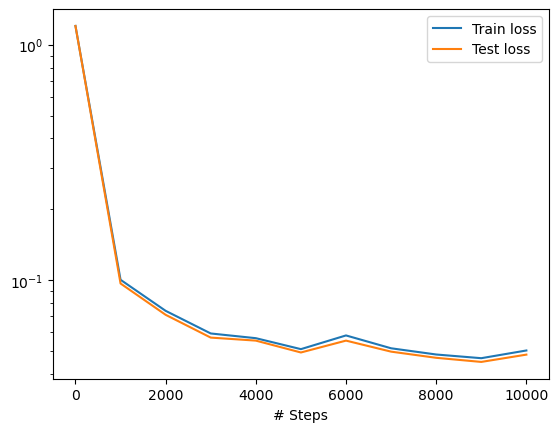

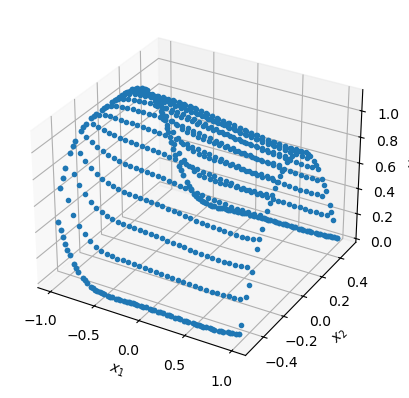

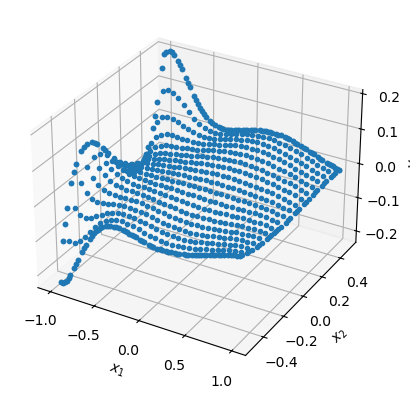

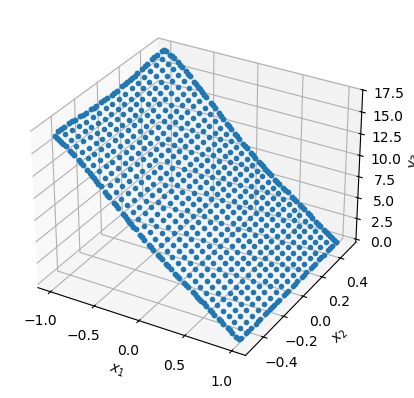

In [39]:
dde.saveplot(losshistory, train_state, issave = True, isplot = True)

In [46]:
samples = geom.random_points(500000)
result = model.predict(samples)

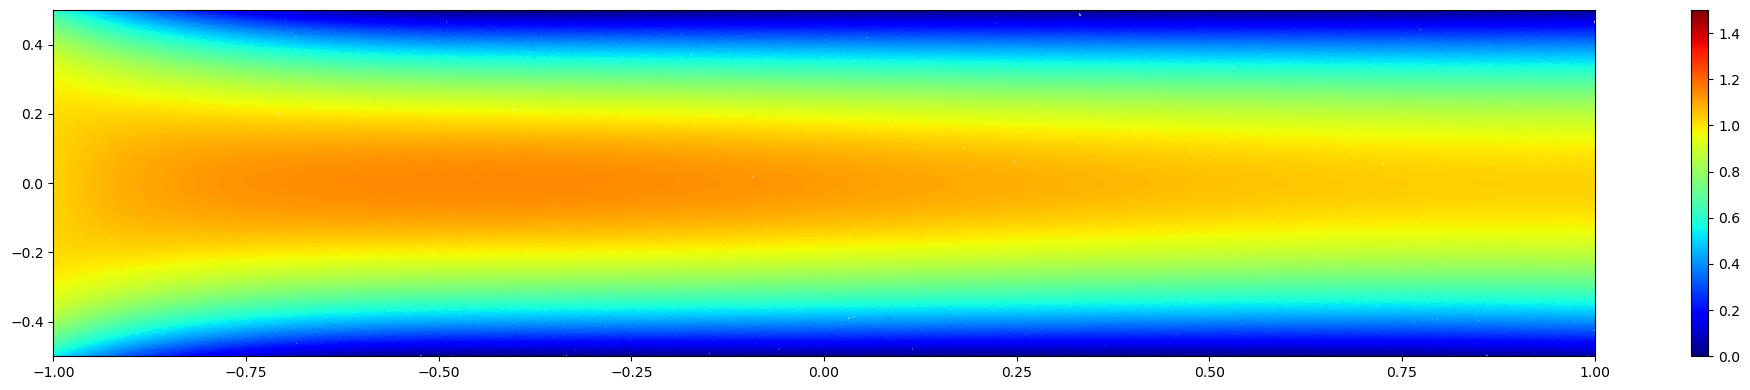

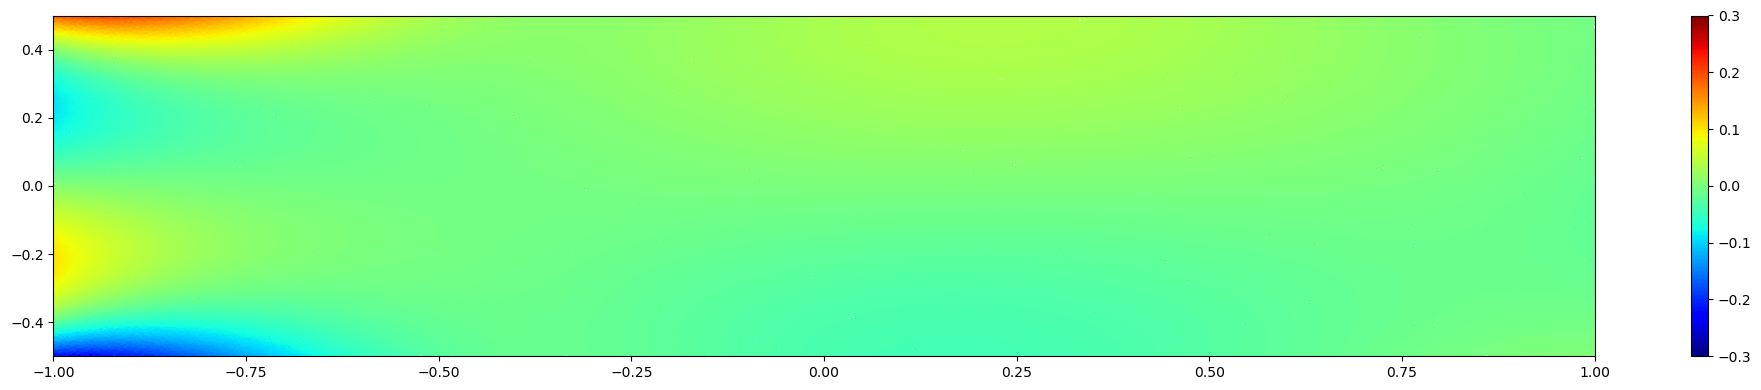

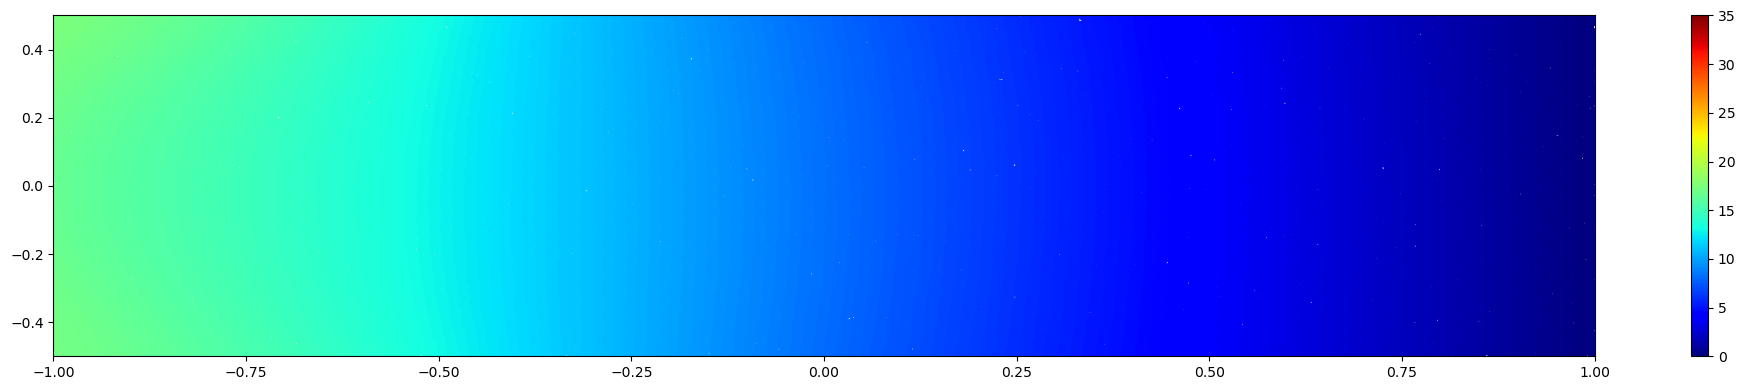

In [47]:
color_legend = [[0,1.5],[-0.3,0.3],[0,35]]

for idx in range(3):
    plt.figure(figsize=(20,4))
    plt.scatter(samples[:,0],
               samples[:,1],
               c = result[:,idx],
               cmap= 'jet',
               s=2)
    plt.colorbar()
    plt.clim(color_legend[idx])
    plt.xlim((0-L/2, L-L/2))
    plt.ylim((0-D/2, D-D/2))
    plt.tight_layout()
    plt.show()

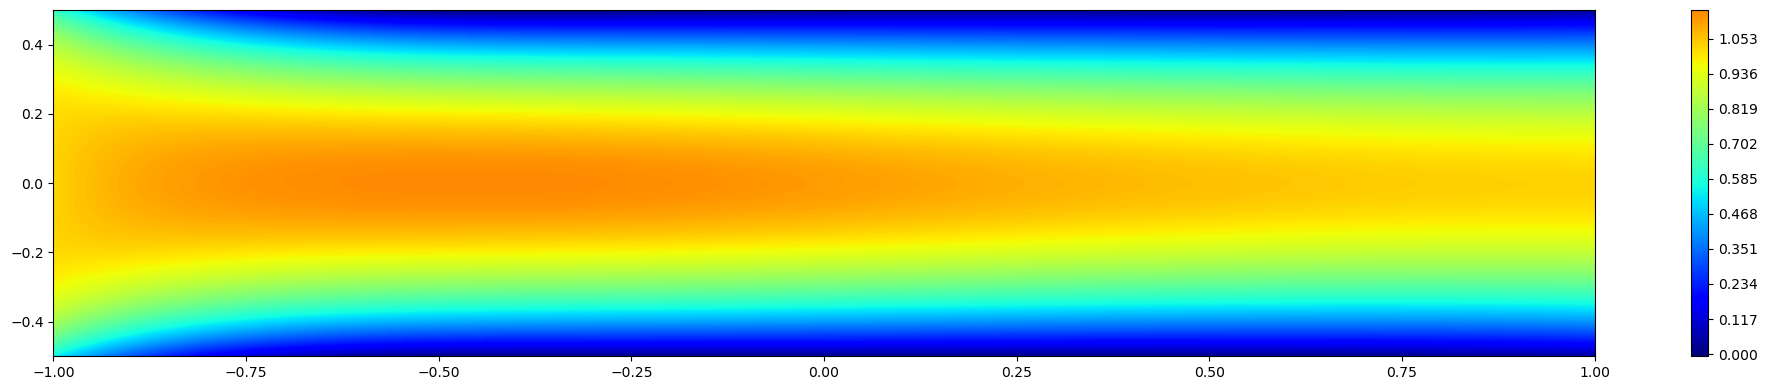

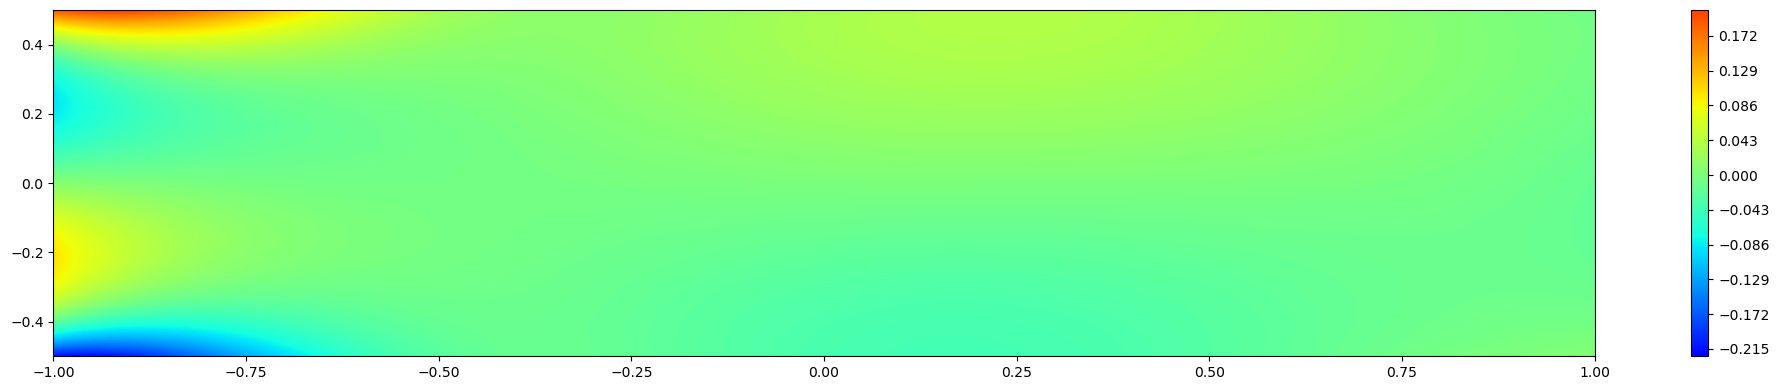

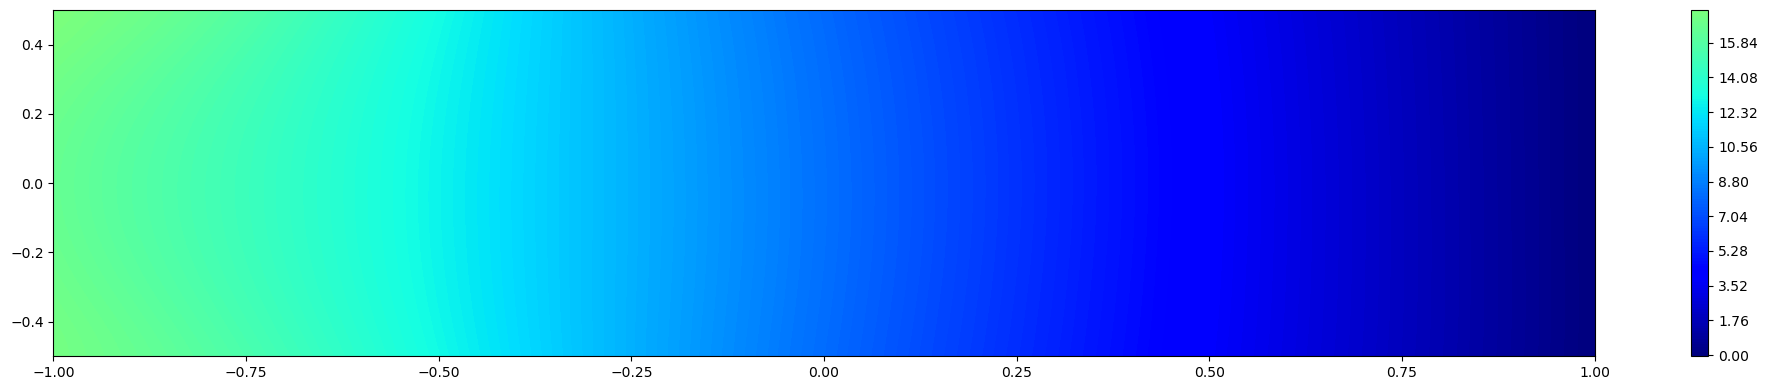

In [49]:
# build grid just for plotting
xg = np.linspace(0 - L/2, L - L/2, 400)
yg = np.linspace(0 - D/2, D - D/2, 300)
X, Y = np.meshgrid(xg, yg)
XY = np.column_stack([X.ravel(), Y.ravel()])

pred = model.predict(XY)  # shape: (400*300, 3)

for idx, clim in enumerate([[0,1.5],[-0.3,0.3],[0,35]]):
    Z = pred[:, idx].reshape(yg.size, xg.size)
    plt.figure(figsize=(20,4))
    cf = plt.contourf(X, Y, Z, levels=1000, cmap='jet')
    plt.colorbar(cf)
    plt.clim(*clim)
    plt.xlim(0 - L/2, L - L/2)
    plt.ylim(0 - D/2, D - D/2)
    plt.tight_layout()
    plt.show()